In [ ]:
# ANALISIS DE MÉTRICAS DE EXPANSION CLONAL 


In [1]:

# Luego de clustering archivo _clone-pass.tsv se realiza analisis de métricas
# Paquetes y librerías
library(readr)
library(dplyr)
library(ggplot2)
library(viridisLite)
library(tidyr)
library(here)  # para rutas relativas

# actualizar renv despues de la instalación de cada paquete
# renv::snapshot()




Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


here() starts at /Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/notebooks



In [2]:

# Configuración de archivo

carpeta_archivo <- "../data/output"  
nombre_archivo <- "repertorio_A_insilico_100_seqs_clone-pass.tsv"

# Construir ruta relativa
archivo_clones <- here(carpeta_archivo, nombre_archivo)

# Cargar archivo
clones <- read_tsv(archivo_clones)
head(clones, 5)

Rows: 100 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


sequence_id,sequence,rev_comp,productive,v_call,d_call,j_call,sequence_alignment,germline_alignment,junction,...,j_identity,j_support,fwr1,fwr2,fwr3,fwr4,cdr1,cdr2,cdr3,clone_id
<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
seq15,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCTGGATTCACCTTTGGTGATTATGCTATGAGCTGGTTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTCATTAGAAGCAAAGCTTATGGTGGGACAACAGAATACACCGCGTCTGTGAAAGGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACTAGAGAGAGCAGTTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,FALSE,TRUE,IGHV3-49*01,IGHD6-19*01,IGHJ6*01,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCTGGATTCACCTTT............GGTGATTATGCTATGAGCTGGTTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTCATTAGAAGCAAAGCTTATGGTGGGACAACAGAATACACCGCGTCTGTGAAA...GGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACTAGAGAGAGCAGTTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCTGGATTCACCTTT............GGTGATTATGCTATGAGCTGGTTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTCATTAGAAGCAAAGCTTATGGTGGGACAACAGAATACACCGCGTCTGTGAAA...GGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGTACTAGAGANAGCAGTTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,TGTACTAGAGAGAGCAGTTACTACTACTACGGTATGGACGTCTGG,...,1,2.66e-28,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCAGGGCGGTCCCTGAGACTCTCCTGTACAGCTTCT,ATGAGCTGGTTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTAGGTTTC,GAATACACCGCGTCTGTGAAA...GGCAGATTCACCATCTCAAGAGATGGTTCCAAAAGCATCGCCTATCTGCAAATGAACAGCCTGAAAACCGAGGACACAGCCGTGTATTACTGT,TGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,GGATTCACCTTT............GGTGATTATGCT,ATTAGAAGCAAAGCTTATGGTGGGACAACA,ACTAGAGAGAGCAGTTACTACTACTACGGTATGGACGTC,1
seq19,GAGGTGCAGCTGGTGGAGTCTGGAGGAGGCTTGATCCAGCCTGGGGGGTCCCTGAGACTCTCCTGTGCAGCCTCTGGGTTCACCGTCAGTAGCAACTACATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTCTCAGTTATTTATAGCGGTGGTAGCACATACTACGCAGACTCCGTGAAGGGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGCTGTATCTTCAAATGAACAGCCTGAGAGCCGAGGACACGGCCGTGTATTACTGTGGTATGGGGGTGCACTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,FALSE,TRUE,IGHV3-53*01,"IGHD3-16*01,IGHD3-16*02,IGHD3-16*03",IGHJ6*01,GAGGTGCAGCTGGTGGAGTCTGGAGGA...GGCTTGATCCAGCCTGGGGGGTCCCTGAGACTCTCCTGTGCAGCCTCTGGGTTCACCGTC............AGTAGCAACTACATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTCTCAGTTATTTATAGCGGT.........GGTAGCACATACTACGCAGACTCCGTGAAG...GGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGCTGTATCTTCAAATGAACAGCCTGAGAGCCGAGGACACGGCCGTGTATTACTGTGGTATGGGGGTGCACTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,GAGGTGCAGCTGGTGGAGTCTGGAGGA...GGCTTGATCCAGCCTGGGGGGTCCCTGAGACTCTCCTGTGCAGCCTCTGGGTTCACCGTC............AGTAGCAACTACATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTCTCAGTTATTTATAGCGGT.........GGTAGCACATACTACGCAGACTCCGTGAAG...GGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGCTGTATCTTCAAATGAACAGCCTGAGAGCCGAGGACACGGCCGTGTATTACTGTGNNNTGGGGGNNNACTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,TGTGGTATGGGGGTGCACTACTACTACTACGGTATGGACGTCTGG,...,1,1.81e-29,GAGGTGCAGCTGGTGGAGTCTGGAGGA...GGCTTGATCCAGCCTGGGGGGTCCCTGAGACTCTCCTGTGCAGCCTCT,ATGAGCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGGAGTGGGTCTCAGTT,TACTACGCAGACTCCGTGAAG...GGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGCTGTATCTTCAAATGAACAGCCTGAGAGCCGAGGACACGGCCGTGTATTACTGT,TGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,GGGTTCACCGTC............AGTAGCAACTAC,ATTTATAGCGGT.........GGTAGCACA,GGTATGGGGGTGCACTACTACTACTACGGTATGGACGTC,2
seq7,CAGGTGCAGCTACAGCAGTGGGGCGCAGGACTGTTGAAGCCTTCGGAGACCCTGTCCCTCACCTGCGCTGTCTATGGTGGGTCCTTCAGTGGTTACTACTGGAGCTGGATCCGCCAGCCCCCAGGGAAGGGGCTGGAGTGGATTGGGGAAATCAATCATAGTGGAAGCACCAACTACAACCCGTCCCTCAAGAGTCGAGTCACCATATCAGTAGACACGTCCAAGAACCAGTTCTCCCTGAAGCTGAGCTCTGTGACCGCCGCGGACACGGCTGTGTATTACTGTGCGAGAGGTACTAACTACTACTACTACGGTATGGACGTCTGGGGGCAAGGGACCACGGTCACCGTCTCCTCA,FALSE,TRUE,IGHV4-34*01,"IGHD1-26*01,

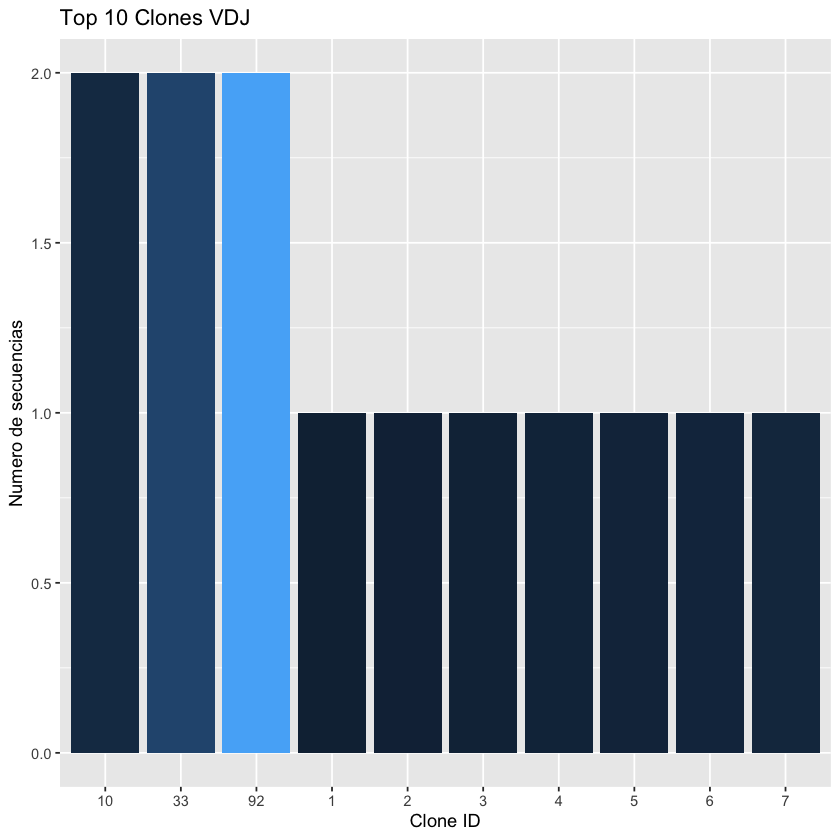

In [3]:
# Tamaño de cada clon

clon_size <- clones %>%
  group_by(clone_id) %>%
  summarise(n_seq = n(), .groups = "drop") %>%
  arrange(desc(n_seq)) %>%
  mutate(freq = n_seq / sum(n_seq))

# Top 10 clones

top10 <- arrange(clon_size, desc(freq)) %>%
  slice_head(n = 10)

ggplot(top10, aes(x = reorder(clone_id, -n_seq), y = n_seq, fill = clone_id)) +
  geom_col() +
  labs(title = "Top 10 Clones VDJ", x = "Clone ID", y = "Numero de secuencias") +
  theme(legend.position = "none")

In [4]:

readr::write_tsv(top10, "../results/expansion/top10_A_100seqs.tsv")

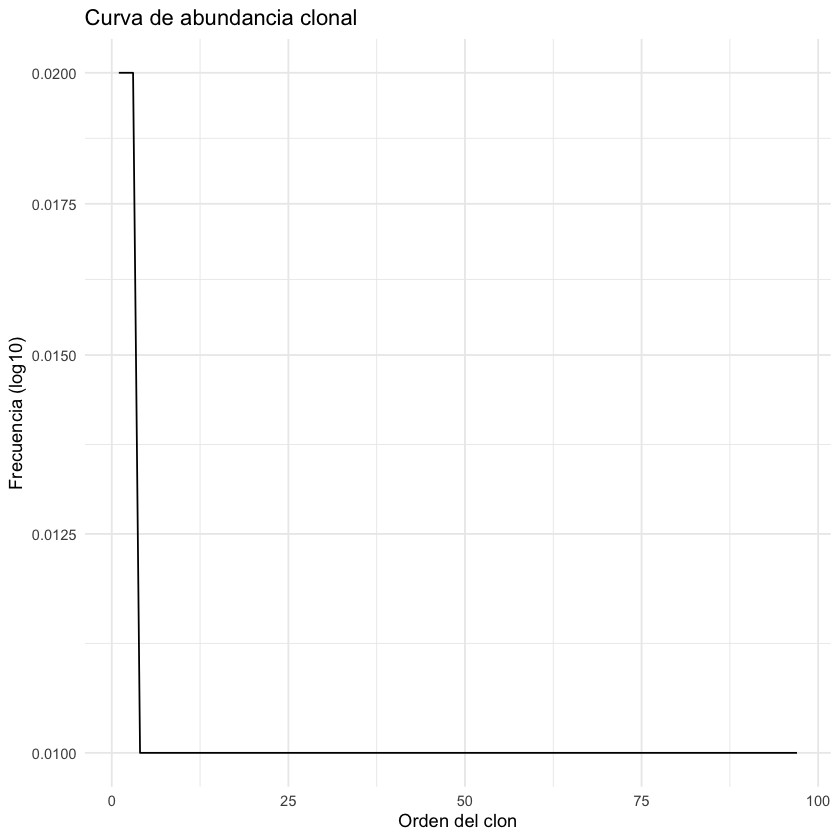

In [5]:

clon_abundancia <- clon_size %>%
  mutate(rank = row_number())

ggplot(clon_abundancia, aes(x = rank, y = freq)) +
  geom_line() +
  scale_y_log10() +
  labs(
    title = "Curva de abundancia clonal", x = "Orden del clon", y = "Frecuencia (log10)") +
  theme_minimal()


In [6]:
readr::write_tsv(clon_abundancia, "../results/expansion/curva_abundancia_A_100seqs.tsv")

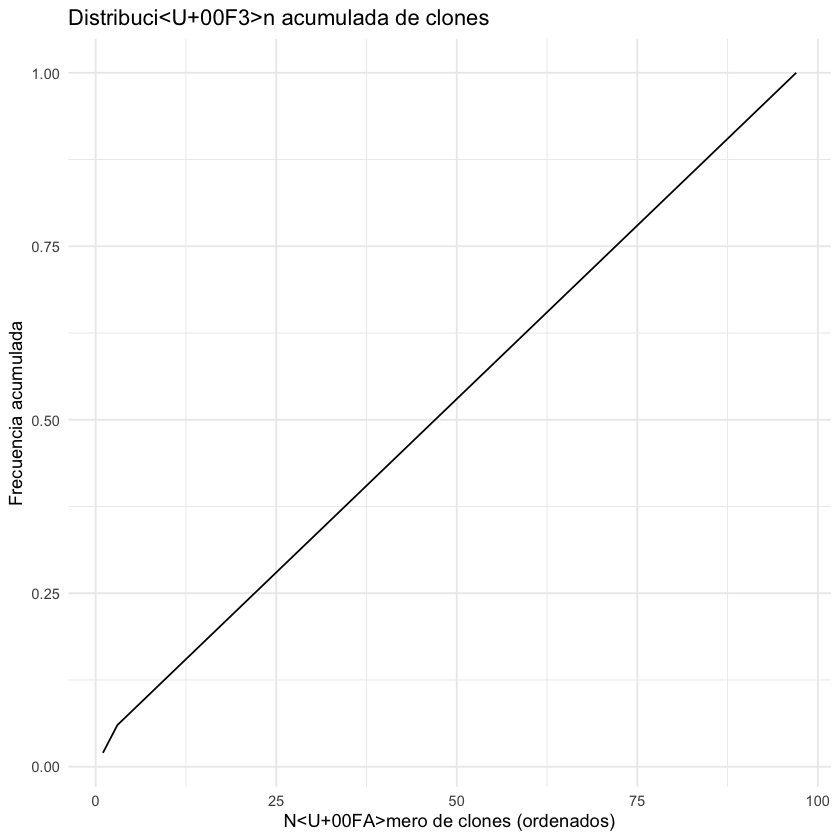

In [7]:
# Distribución acumulada

dist_acumulada <- clon_size %>%
  mutate(cum_freq = cumsum(freq), rank = row_number()) 

ggplot(dist_acumulada, aes(x = rank, y = cum_freq)) +
  geom_line() +
  labs(title = "Distribución acumulada de clones", x = "Número de clones (ordenados)", y = "Frecuencia acumulada") +
  theme_minimal()

In [8]:
readr::write_tsv(dist_acumulada, "../results/expansion/dist_acumulada_A_100seqs.tsv")